Module importations

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings as wr
wr.filterwarnings('ignore')


Load and Previsualize datasets

In [184]:
#Load transaction data
transaction_df = pd.read_csv('data/train/transactions_v2.csv')
transaction_df.head(1)

,transaction_id,sender_id,recipient_id,transaction_type,amount,location,payment_method,sender_iban,recipient_iban,balance_after,description,timestamp
0,dc9fb3e7-8c7d-426f-a700-a0fc7e96941c,LDCK-SLVT-7F8-MUN-0,NaN,in-person payment,269.58,Munich - Isar River Cafe,debit card,DE71D4674228693667840434176,IT48W5478109561792252177824866,45208.46,NaN,2087-01-01T08:48:17


In [185]:
transaction_df.isnull().sum()

transaction_id         0
sender_id              0
recipient_id         912
transaction_type       0
amount                 0
location             779
payment_method       779
sender_iban            0
recipient_iban       341
balance_after          0
description         1238
timestamp              0
dtype: int64

In [186]:
#Load locations data
location_df = pd.read_json('data/train/locations.json')
location_df.head(1)

,biotag,timestamp,lat,lng,city
0,DÖHN-GDUI-811-WIE-0,2087-01-01 06:34:59,50.0978,8.1756,Wiesbaden


In [187]:
#Load mails dataset
pd.set_option("display.max_rows",None)
mail_df = pd.read_json('data/train/mails.json')
mail_df.head(2)

,mail
0,"From: ""Emily Carter"" <newsletter@studyhub.com>..."
1,"From: ""Blue Harbor Customer Support"" <orders@b..."


In [188]:
#Load sms data
sms_df = pd.read_json('data/train/sms.json')
sms_df.head(2)

,sms
0,From: Wiesbaden Student Services\nTo: +1785934...
1,From: Student Services\nTo: +17859340115\nDate...


In [189]:
#Load user data
user_df = pd.read_json('data/train/users.json')

#user_df own columns residence who are json
residence_df = pd.json_normalize(user_df['residence'])

#Concatenation between user_df and residence_df
user_df = pd.concat(
    [user_df.drop(columns=['residence']),residence_df],axis=1
)

user_df.head(2)


,first_name,last_name,birth_year,salary,job,iban,description,city,lat,lng
0,Guido,Döhn,2065,12700,Student,DE74X8794356022735306376013,Guido Döhn ist ein 22-jähriger Student aus Wie...,Wiesbaden,50.0825,8.2400
1,Aimée,Blondel,2046,29500,Administrative Assistant,FR90R8489055650539701833516,"Aimée Blondel, née en 2046, a 41 ans et vit à ...",Paris,48.8567,2.3522


Merge beetween transaction_df and user_df

In [190]:
#Renomer description,location sur transaction_df
transaction_df.rename(columns={'description':'transaction_description','location':'transaction_location'},inplace=True)

#Merge suivant sender_iban
df_merged_1 = pd.merge(transaction_df,user_df,left_on="sender_iban",right_on="iban",how='left',suffixes=["","_sender"])
df_merged_1.head(2)

#Merge suivant recipient_iban
df_merged = pd.merge(df_merged_1,user_df,left_on="recipient_iban",right_on="iban",how="left",suffixes=["","_recipient"])
df_merged.tail(2)

,transaction_id,sender_id,recipient_id,transaction_type,amount,transaction_location,payment_method,sender_iban,recipient_iban,balance_after,transaction_description,timestamp,first_name,last_name,birth_year,salary,job,iban,description,city,lat,lng,first_name_recipient,last_name_recipient,birth_year_recipient,salary_recipient,job_recipient,iban_recipient,description_recipient,city_recipient,lat_recipient,lng_recipient
2015,ff4dcd6e-48aa-432e-9548-11ec7b018ad6,SPNC-SRAA-7F1-IND-0,NaN,in-person payment,113.87,Indianapolis - Fountain Square Provisions,smartwatch,US86K4608896011535163593949,IT36M6339377593524010795514433,33782.08,NaN,2088-01-27T17:02:42,Sara,Spencer,2033.0,46700.0,Retail Entrepreneur,US86K4608896011535163593949,"Sara Spencer, born in 2033 and now 54, is a Ho...",Indianapolis,39.7771,-86.1458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016,0d3d0fb4-72c5-403c-affe-48cdb79f193c,MSIE-BRNT-7D5-ARN-1,NaN,in-person payment,44.08,Arnsberg - Arnsberg Coffee House,debit card,DE60P8383513020579134833709,IT24B5054643419387333915047496,16018.18,NaN,2088-01-29T10:44:58,Bernt,Mies,2005.0,29600.0,Retired,DE60P8383513020579134833709,"Bernt Mies, Jahrgang 2005, lebt als 82‑jährige...",Arnsberg,51.3833,8.0833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [191]:
#Renommer les colonnes du dataframe df_merged
df_merged.rename(columns={
    'first_name':'first_name_sender',
    'last_name':'last_name_sender',
    'birth_year':'birth_year_sender',
    'salary':'salary_sender',
    'job':'job_sender',
    'description':'description_sender',
    'city':'city_sender',
    'lat':'lat_sender',
    'lng':'lng_sender'
},inplace=True)

Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [192]:
#Check missing value
df_merged.isnull().sum()

transaction_id                0
sender_id                     0
recipient_id                912
transaction_type              0
amount                        0
transaction_location        779
payment_method              779
sender_iban                   0
recipient_iban              341
balance_after                 0
transaction_description    1238
timestamp                     0
first_name_sender           264
last_name_sender            264
birth_year_sender           264
salary_sender               264
job_sender                  264
iban                        264
description_sender          264
city_sender                 264
lat_sender                  264
lng_sender                  264
first_name_recipient       1873
last_name_recipient        1873
birth_year_recipient       1873
salary_recipient           1873
job_recipient              1873
iban_recipient             1873
description_recipient      1873
city_recipient             1873
lat_recipient              1873
lng_reci

In [193]:
#Check duplicated
df_merged.duplicated().sum()

np.int64(0)

In [194]:
#Data type
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           2017 non-null   str    
 1   sender_id                2017 non-null   str    
 2   recipient_id             1105 non-null   str    
 3   transaction_type         2017 non-null   str    
 4   amount                   2017 non-null   float64
 5   transaction_location     1238 non-null   str    
 6   payment_method           1238 non-null   str    
 7   sender_iban              2017 non-null   str    
 8   recipient_iban           1676 non-null   str    
 9   balance_after            2017 non-null   float64
 10  transaction_description  779 non-null    str    
 11  timestamp                2017 non-null   str    
 12  first_name_sender        1753 non-null   str    
 13  last_name_sender         1753 non-null   str    
 14  birth_year_sender        1753 non-n

In [180]:
#Number of unique value for each cat column
print("Value contening in ")
print(df[''].unique())

Value contening in 


NameError: name 'df' is not defined

In [195]:
#Check statistic of dataset
df_merged.describe()

,amount,balance_after,birth_year_sender,salary_sender,birth_year_recipient,salary_recipient
count,2017.000000,2017.000000,1753.000000,1753.000000,144.000000,144.00000
mean,397.823580,18173.222062,2031.474615,36082.201940,2031.000000,35750.00000
std,918.813998,16115.611788,26.151223,22576.664225,26.609846,21736.99756
min,3.190000,208.260000,1994.000000,12700.000000,1994.000000,12700.00000
25%,43.900000,6964.600000,2004.000000,26300.000000,2003.750000,26125.00000
50%,100.150000,14025.790000,2040.000000,29600.000000,2036.500000,29550.00000
75%,261.630000,20239.200000,2055.000000,37000.000000,2056.250000,38750.00000
max,8480.640000,75059.820000,2065.000000,100000.000000,2065.000000,100000.00000


In [196]:
df_merged.columns

Index(['transaction_id', 'sender_id', 'recipient_id', 'transaction_type',
       'amount', 'transaction_location', 'payment_method', 'sender_iban',
       'recipient_iban', 'balance_after', 'transaction_description',
       'timestamp', 'first_name_sender', 'last_name_sender',
       'birth_year_sender', 'salary_sender', 'job_sender', 'iban',
       'description_sender', 'city_sender', 'lat_sender', 'lng_sender',
       'first_name_recipient', 'last_name_recipient', 'birth_year_recipient',
       'salary_recipient', 'job_recipient', 'iban_recipient',
       'description_recipient', 'city_recipient', 'lat_recipient',
       'lng_recipient'],
      dtype='str')

Copy du dataset df_merged à df_model

In [197]:
df_model = df_merged.copy()

In [198]:
#Les valeur vide salary_sender et sender_recipient vont prendre la moyenne
df_model['salary_sender']=df_model['salary_sender'].fillna(df_model['salary_sender'].mean())
df_model['salary_recipient']=df_model['salary_recipient'].fillna(df_model['salary_recipient'].mean())

In [199]:
df_model.drop(columns=['transaction_id','sender_id','recipient_id','sender_iban','recipient_iban','iban','iban_recipient'],inplace=True)

In [200]:
df_model.columns

Index(['transaction_type', 'amount', 'transaction_location', 'payment_method',
       'balance_after', 'transaction_description', 'timestamp',
       'first_name_sender', 'last_name_sender', 'birth_year_sender',
       'salary_sender', 'job_sender', 'description_sender', 'city_sender',
       'lat_sender', 'lng_sender', 'first_name_recipient',
       'last_name_recipient', 'birth_year_recipient', 'salary_recipient',
       'job_recipient', 'description_recipient', 'city_recipient',
       'lat_recipient', 'lng_recipient'],
      dtype='str')

### Variables transactionnelles

In [201]:
df_model['amount'].describe()

count    2017.000000
mean      397.823580
std       918.813998
min         3.190000
25%        43.900000
50%       100.150000
75%       261.630000
max      8480.640000
Name: amount, dtype: float64

Visualisation des distributions

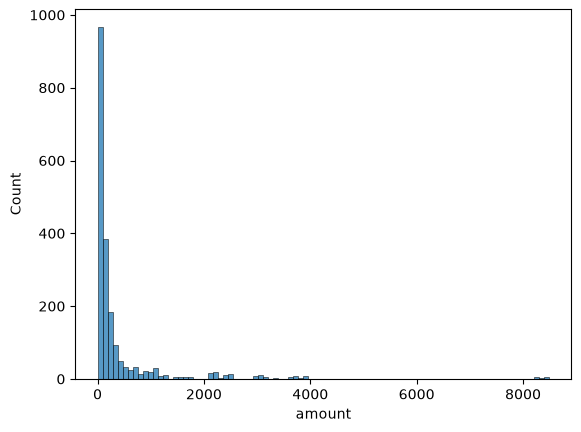

In [202]:
sns.histplot(df_model['amount'])
plt.show()

In [203]:
#Application du log sur amount afin de reduire les valeurs extrèmes
df_model['amount_log']=np.log1p(df_model['amount'])
df_model['amount_log'].head(2)

0    5.600568
1    3.930845
Name: amount_log, dtype: float64

In [204]:
df_model['salary_sender'].isna().sum()

np.int64(0)

In [205]:
#Creation d'une variable amount_salary_ration pour le sender
df_model['amount_salary_ration'] = df_model['amount']/df_model['salary_sender']
df_model['amount_salary_ration'].head(3)

0    0.002696
1    0.000500
2    0.060585
Name: amount_salary_ration, dtype: float64

### Variables temporelles

In [206]:
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])
df_model['month'] = df_model['timestamp'].dt.month
df_model['day_of_week'] = df_model['timestamp'].dt.day_of_week
df_model['day'] = df_model['timestamp'].dt.day
df_model['hour'] = df_model['timestamp'].dt.hour
df_model['minute'] = df_model['timestamp'].dt.minute
df_model['second'] = df_model['timestamp'].dt.second

In [207]:
df_model[['timestamp','month','day_of_week','day','hour','minute','second']].head(1)


,timestamp,month,day_of_week,day,hour,minute,second
0,2087-01-01 08:48:17,1,2,1,8,48,17


### Feature géographique

In [208]:
df_model['lat_sender'].isna().sum()

np.int64(264)

In [210]:
df_model.columns

Index(['transaction_type', 'amount', 'transaction_location', 'payment_method',
       'balance_after', 'transaction_description', 'timestamp',
       'first_name_sender', 'last_name_sender', 'birth_year_sender',
       'salary_sender', 'job_sender', 'description_sender', 'city_sender',
       'lat_sender', 'lng_sender', 'first_name_recipient',
       'last_name_recipient', 'birth_year_recipient', 'salary_recipient',
       'job_recipient', 'description_recipient', 'city_recipient',
       'lat_recipient', 'lng_recipient', 'amount_log', 'amount_salary_ration',
       'month', 'day_of_week', 'day', 'hour', 'minute', 'second'],
      dtype='str')

In [216]:
df_model['lat_sender'] = pd.to_numeric(df_model['lat_sender'],errors="coerce")
df_model['lng_sender'] = pd.to_numeric(df_model['lng_sender'],errors="coerce")

df_model['lat_recipient'] = pd.to_numeric(df_model['lat_recipient'],errors="coerce")
df_model['lng_recipient'] = pd.to_numeric(df_model['lng_recipient'],errors="coerce")

In [ ]:
df_model['lat_sender'].fillna(0)
df_model['lng_sender'].fillna(0)
df_model['lat_recipient'].fillna(0)
df_model['lng_recipient'].fillna(0)


In [ ]:
df_model['lat_sender'].isna().sum()

A revoir

In [ ]:
from haversine import haversine, Unit

df_model['distance_km']=df_model.apply(
    lambda row: haversine(
        (row["lat_sender"],row["lng_sender"]),
        (row["lat_recipient"],row["lng_recipient"]),
        unit=Unit.KILOMETERS
    ),
    axis=1
)

lat_sender        264
lng_sender        264
lat_recipient    1873
lng_recipient    1873
dtype: int64
  city_sender city_recipient  distance_km
0      Munich            NaN          NaN
1      Munich            NaN          NaN
2         NaN         Nantes          NaN
3         NaN          Ceres          NaN
4      Munich            NaN          NaN


In [ ]:
df_model["same_city"] = (
    df_model["city_sender"] == df_model["city_recipient"]
).astype(int)

In [ ]:
df_model['distance_km'].head()

,city_sender,city_recipient,distance_km
0,Munich,NaN,NaN
1,Munich,NaN,NaN
2,NaN,Nantes,NaN
3,NaN,Ceres,NaN
4,Munich,NaN,NaN
5,Cornebarrieu,NaN,NaN
6,Brindisi,NaN,NaN
7,Brindisi,NaN,NaN
8,Cornebarrieu,NaN,NaN
9,NaN,Aurora,NaN


### Features comportementales : les plus importantes

In [ ]:

#Nombre de transaction par sender
df_model["sender_transaction_count"] = (
    df_merged.groupby("sender_iban")["transaction_id"]
    .transform("count")
)

In [ ]:
#Nombre de destinataire different
df_model['sender_unique_recipients']=(
    df_merged.groupby("sender_iban")["recipient_iban"]
    .transform("nunique")
)

In [ ]:
#Montant moyen envoyer
df_model['sender_average_amount'] =(
    df_merged.groupby("sender_iban")["amount"]
    .transform('mean')
)

In [ ]:
#Ecart entre montant envoyer et moyen de amount
df_model['amount_vs_sender_avg']=df_model['amount']/df_model['sender_average_amount']

### Fréquence des transactions

### Une feature très intéressante : destinataire inconnu

Dataset for unsupervised learning
amount
balance_after
amount_log

amount_salary_ratio

distance_km
same_city

hour_sin
hour_cos
dow_sin
dow_cos

sender_transaction_count
sender_unique_recipients
sender_avg_amount
amount_vs_sender_avg

recipient_known

transaction_type
payment_method

age_sender
age_recipient
salary_sender
salary_recipient
job_sender
job_recipient